# **Lyotropic Gels**

## **Set up()**

In [1]:
%run ../../../setup_workspace.py # ../ means level up 
pi = np.pi
from matplotlib.ticker import ScalarFormatter
import matplotlib.ticker as mticker
from scipy.special import gamma, jv

## **Data**

In [2]:
green = pd.read_csv(r"E:\Zalygin geles\SAXS gels\green.dat", sep=str('  '), 
                      skiprows=5, names=['q', 'I', 'err'], encoding='latin1')
red = pd.read_csv(r"E:\Zalygin geles\SAXS gels\red.dat", sep=str('  '), 
                      skiprows=5, names=['q', 'I', 'err'], encoding='latin1')

C:\Users\LabPCA\AppData\Local\Temp\ipykernel_9692\2727612186.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  green = pd.read_csv(r"E:\Zalygin geles\SAXS gels\green.dat", sep=str('  '),
C:\Users\LabPCA\AppData\Local\Temp\ipykernel_9692\2727612186.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  red = pd.read_csv(r"E:\Zalygin geles\SAXS gels\red.dat", sep=str('  '),


# **Functions**

## S(q)

In [19]:
import numpy as np
from scipy.special import gamma

def hex_structure_factor(q, a, Delta, delta, nu, c):
    """
    Структурный фактор для гексагональной решётки (Förster eq 23-30)
    
    Parameters:
    -----------
    q : array, scattering vector (nm^-1)
    a : float, lattice parameter (nm)
    Delta : float, Debye-Waller factor = sigma_a^2 * a^2 (nm^2)
    delta : float, peak width (nm^-1), related to domain size D = 2*pi/delta
    nu : float, peak shape (0=Lorentzian, inf=Gaussian)
    c : float, normalization constant (~1)
    
    Returns:
    --------
    S : array, structure factor
    """
    # ---- 1. Позиции пиков для HEX (до 5-го порядка) ----
    hk = [(1,0), (1,1), (2,0), (2,1), (3,0), (2,2), (3,1), (4,0), (3,2), (4,1)]
    q_hk = np.array([4*np.pi/(np.sqrt(3)*a) * np.sqrt(h**2 + h*k + k**2) for h,k in hk])
    
    # ---- 2. Мультипликаторы ----
    m = np.array([6 if (h==0 or k==0 or h==k) else 12 for h,k in hk])
    
    # ---- 3. Фактор симметрии (для HEX все = 1) ----
    f = np.ones_like(m)
    
    # ---- 4. Peak shape parameter ----
    gamma_nu = np.pi**0.5 * gamma(nu + 0.5) / gamma(nu/2) if nu > 0 else 0
    
    # ---- 5. Суммируем пики ----
    Z0 = np.zeros_like(q)
    
    for i, q0 in enumerate(q_hk):
        x = 2 * (q - q0) / (np.pi * delta)
        
        # Peak shape
        if nu < 0.001:
            # Lorentzian limit
            L = (delta / (2*np.pi)) / (x**2 + (delta/2)**2)
        elif nu > 1000:
            # Gaussian limit
            L = (2/(np.pi*delta)) * np.exp(-4*x**2 / (np.pi*delta**2))
        else:
            # General case (eq 27)
            numerator = gamma(nu/2 + 1j * gamma_nu * x)
            denominator = gamma(nu/2)
            L = (2/(np.pi*delta)) * np.abs(numerator / denominator)**2
        
        # Prefactor: c / (sqrt(3) * a^2 * q)  (eq 23 + Table 3)
        prefactor = c / (np.sqrt(3) * a**2 * q)
        
        Z0 += prefactor * m[i] * f[i]**2 * L
    
    # ---- 6. Дебая-Валлер (eq 25) ----
    G = np.exp(-Delta * q**2)
    
    # ---- 7. Структурный фактор (eq 30) ----
    S = 1 + (Z0 - 1) * G
    
    # ---- 8. Обрезка артефактов ----
    # S = np.maximum(S, 0.01)
    
    return S

## P(q)

In [97]:
def cylinder_amplitude(q, R):
    qR = q * R + 1e-10
    return 2 * np.pi * R**2 * j1(qR) / qR

def cylinder_form_factor(q, R, scale=1.0, bg=0.0):
    F = cylinder_amplitude(q, R)
    P = np.abs(F)**2 / (q + 1e-10)
    return scale * P + bg

def cylinder_core_shell(q, R_core, R_shell, rho_core, rho_shell, scale=1.0, bg=0.0):

    F_core = cylinder_amplitude(q, R_core)
    F_shell = cylinder_amplitude(q, R_shell)
    
    F = rho_core * F_core + rho_shell * (F_shell - F_core)
    
    P = np.abs(F)**2 / (q + 1e-10)
    return scale * P + bg

## Analysis

In [108]:
def model_hex(
    q, a, Delta, delta, nu, c,
    R_core, R_shell,
    rho_core, rho_shell,
    scale, bg
):
    Sq = hex_structure_factor(
        q, a, Delta, delta, nu, c
    )

    Pq = cylinder_core_shell(
        q,
        R_core,
        R_shell,
        rho_core,
        rho_shell,
        1.0,
        0.0
    )

    return scale * Pq * Sq + bg

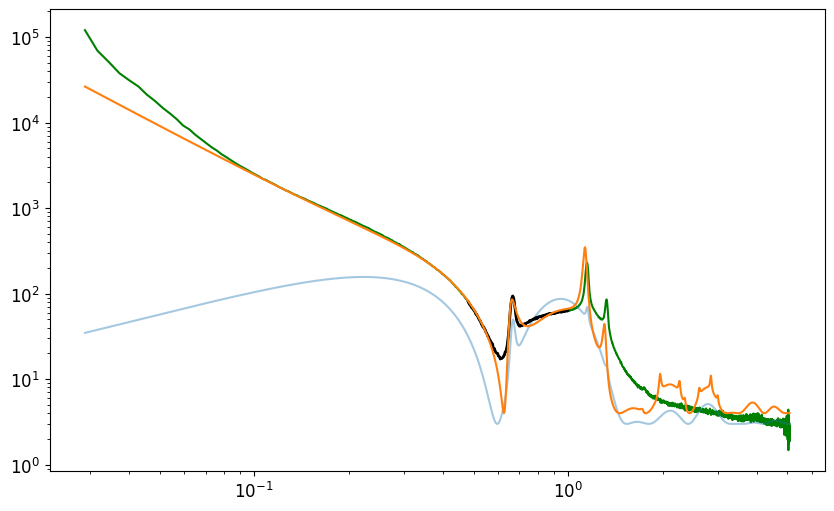

In [183]:
q, I = green['q'], green['I'] / 1e3

plt.loglog(q, I, color='green')
p0 = [
    10.9,    # a
    0.9,     # Delta
    0.015,   # delta
    1.0,     # nu
    1.0,     # c
    1.8,     # R_core (нм)
    5.3,     # R_shell (нм) ← максимум 5.45
    -0.044,  # rho_core
    0.056,  # rho_shell
    80.0,    # scale
    3.0      # bg
]

bounds = (
    [10.0, 0.0, 0.001, 0.001, 0.5, 1.0, 3.0, -0.1, 0.0, 0.0, 0.0],
    [12.0, 3.0, 0.1, 10.0, 2.0, 4.0, 5.4, -0.03, 0.08, np.inf, 4.0]
)

Sq = hex_structure_factor(q, *p0[:5])
# plt.plot(q, Sq, color='b', alpha=.1)

Pq = cylinder_core_shell(q, *p0[5:])
# plt.plot(q, Pq, color='r', alpha=.1)

plt.plot(q, model_hex(q, *p0), alpha=.4)

mask = (q>.48)*(q<1.)
plt.plot(q[mask], I[mask], color='black', linewidth=2)

p, cov = curve_fit(model_hex, q[mask], I[mask], p0=p0, bounds=bounds, maxfev=6000,)
plt.plot(q, model_hex(q, *p))

Pq = cylinder_core_shell(q, *p[5:])
# plt.plot(q, Pq, color='r', alpha=.1)

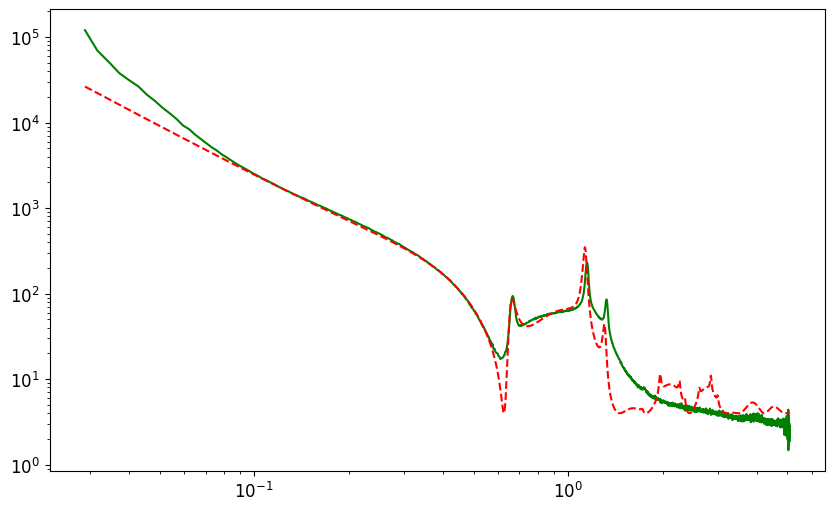

In [187]:
plt.loglog(q, I, color='green')
plt.plot(q, model_hex(q, *p), color='r', linestyle='--')

In [188]:
### Параметры (порядок из model_hex)
names = [
    'a (nm)',
    'Delta (nm^2)',
    'delta (nm^-1)',
    'nu',
    'c',
    'R_core (nm)',
    'R_shell (nm)',
    'rho_core (el/A^3)',
    'rho_shell (el/A^3)',
    'scale',
    'bg'
]

print("\n" + "="*50)
print("RESULTS")
print("="*50)
for i, name in enumerate(names):
    print(f"{name:20} = {p[i]:.4f}")

# Дополнительно: размер домена
D = 2 * np.pi / p[2]  # delta
print(f"\nDomain size D = {D:.1f} nm")

# Толщина оболочки
t_shell = p[6] - p[5]  # R_shell - R_core
print(f"Shell thickness = {t_shell:.2f} nm")


RESULTS
a (nm)               = 11.0909
Delta (nm^2)         = 0.0624
delta (nm^-1)        = 0.0343
nu                   = 0.0025
c                    = 2.0000
R_core (nm)          = 1.6547
R_shell (nm)         = 5.4000
rho_core (el/A^3)    = -0.0300
rho_shell (el/A^3)   = 0.0800
scale                = 292.3411
bg                   = 4.0000

Domain size D = 183.1 nm
Shell thickness = 3.75 nm


## Peak posit

In [43]:
x = np.array([0.666, 1.149, 1.326, 1.751])
print(x / 0.666)
print(x ** 2 / 0.666 ** 2)
print('Hexagonal')

[1.         1.72522523 1.99099099 2.62912913]
[1.         2.97640208 3.96404513 6.91231998]
Hexagonal


In [46]:
x = np.array([0.5547, 0.9101, 1.056, 1.103, 1.286, 1.391])
print(x / 0.5547)
print((x / 0.5547)**2 * 3)
print('FCC')

[1.         1.64070669 1.90373175 1.98846223 2.31837029 2.5076618 ]
[ 3.          8.07575531 10.87258369 11.86194614 16.12452241 18.8651031 ]
FCC
